# Pilot 2: local reference images

Use a small local Mucha corpus to make attractive cover or inline images for WeChat articles. Article text is not an input. This notebook keeps image selection and each paid generation call explicit. Pilot 1 remains separate.


In [1]:
from pathlib import Path
from dotenv import load_dotenv
from IPython.display import display
from graphic_design_helper.images import compare_images
from graphic_design_helper.reference_generation import (
    build_request, generate_from_references, load_corpus, search_corpus,
)

# Jupyter may start in the repository root or the notebook directory.
working_dir = Path.cwd().resolve()
project_root = next(
    (candidate for candidate in (working_dir, *working_dir.parents)
     if (candidate / "pyproject.toml").is_file()
     and (candidate / "experiments" / "pilot2" / "corpus" / "manifest.json").is_file()),
    None,
)
if project_root is None:
    raise RuntimeError("Open this notebook from a folder inside the project.")
load_dotenv(project_root / ".env", override=False)
pilot_dir = project_root / "experiments" / "pilot2"
items = load_corpus(pilot_dir / "corpus")
print(f"Loaded {len(items)} local reference images.")


Loaded 7 local reference images.


## Browse references

Search by a visual word or leave the query empty. The corpus was imported from museum records marked CC0. Source pages remain attached to every item.



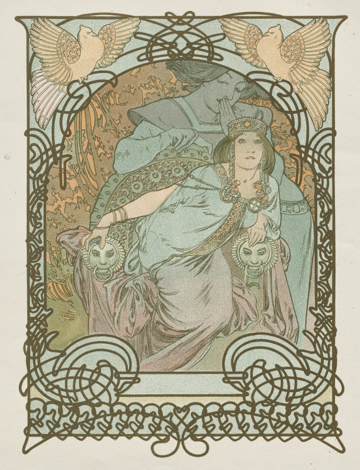
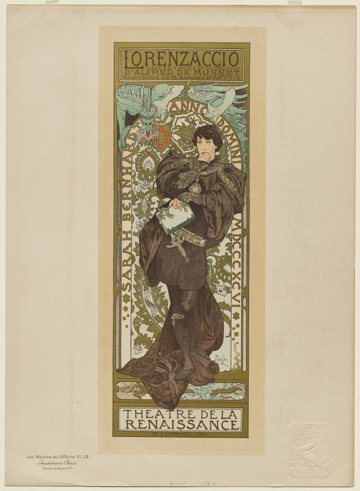

148901 | Ilsee, Princesse de Tripoli | figure, illustration, border, gold, 人物, 插画
  Source: https://clevelandart.org/art/1977.1018
147115 | Lorenzaccio | figure, poster, border, olive, gold, 人物, 海报
  Source: https://clevelandart.org/art/1973.1018


In [2]:
query = "人物"  # Examples: floral, gold, figure, 花卉, 人物
selected_tags = []  # Optional exact tag filters
matches = search_corpus(items, query, selected_tags)
if matches:
    display(compare_images([item["path"] for item in matches],
                           [f"{item['id']} · {item['title']}" for item in matches], width=180))
for item in matches:
    print(item["id"], "|", item["title"], "|", ", ".join(item["tags"]))
    print("  Source:", item["source_url"])


## Choose references and preview

Select one to three IDs from the gallery. A cover and an inline illustration use different pilot image sizes; neither needs to represent the article. Review the exact prompt and sources below before generation.


In [3]:
selected_ids = [matches[0]["id"]] if matches else []
role = "cover"  # "cover" or "illustration"
mood = "elegant and inviting"
palette = "harmonious muted colors"
motifs = "floral curves and decorative linework"
extra = ""
quality = "medium"

request = build_request(items, selected_ids, role=role, mood=mood,
                        palette=palette, motifs=motifs, extra=extra,
                        quality=quality)
print("Size:", request["settings"]["size"])
print("\nReferences:")
for reference in request["references"]:
    print("-", reference["title"], "|", reference["source_url"], "|", reference["license"])
print("\nExact image prompt:\n")
print(request["prompt"])


Size: 1280x544

References:
- Ilsee, Princesse de Tripoli | https://clevelandart.org/art/1977.1018 | CC0

Exact image prompt:

Create a new, visually appealing cover image at 1280x544. This is an aesthetic image for a WeChat article; it does not need to depict or explain the article text.

Use the attached historical images as visual references for line rhythm, ornament, palette, and composition. Create a distinct new arrangement. Do not reproduce a reference image, its lettering, signature, brand name, or exact figure. Do not include any visible text, logos, watermarks, or borders from the source images.

Reference notes:
- Reference 1: Ilsee, Princesse de Tripoli; visual features: figure, illustration, border, gold, 人物, 插画.

Desired mood: elegant and inviting
Palette: harmonious muted colors
Preferred motifs: floral curves and decorative linework
Additional direction: none
Keep the image attractive at thumbnail size and leave enough visual breathing room.


## Generate one image

Set `GENERATE` to `True` only after reviewing the request above. This makes one paid image API call and saves a new attempt with its references, prompt, status, and output. Rerun the preview cell after changing your choices.


Saved: D:\DH-Research\graphic-design-helper\experiments\pilot2\outputs\attempt_03\image.png



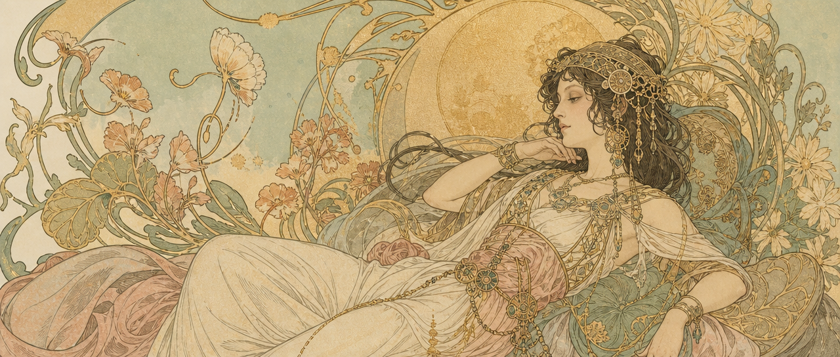

In [4]:
GENERATE = True
if GENERATE:
    current = build_request(items, selected_ids, role=role, mood=mood,
                            palette=palette, motifs=motifs, extra=extra,
                            quality=quality)
    if current["review_token"] != request["review_token"]:
        raise ValueError("The selection or direction changed. Rerun the preview cell.")
    result = generate_from_references(request,
                                      approved_token=request["review_token"],
                                      output_dir=pilot_dir / "outputs")
    print("Saved:", result["image_path"])
    display(compare_images([result["image_path"]], ["New image"], width=420))
else:
    print("No generation call made. Review the preview, then set GENERATE = True.")


## Compare saved images

Saved attempts remain separate. Inspect the output at the size and crop used by your publishing editor before posting.



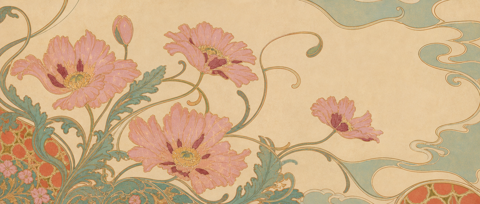
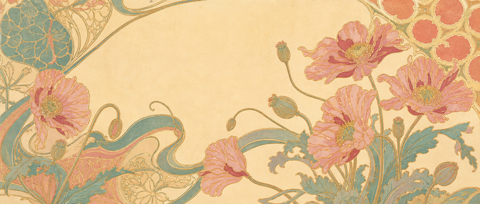
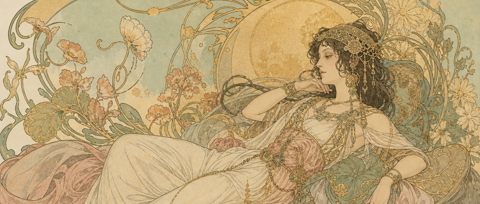

In [5]:
saved = sorted((pilot_dir / "outputs").glob("attempt_*/image.png"))
if saved:
    display(compare_images(saved[-6:], [path.parent.name for path in saved[-6:]], width=240))
else:
    print("No generated images yet.")
